Build a model that can predict the primary contributory cause of a car accident, given information about the car, the people in the car, the road conditions etc. You might imagine your audience as a Vehicle Safety Board who's interested in reducing traffic accidents, or as the City of Chicago who's interested in becoming aware of any interesting patterns.

Objective 1: Analyze Environmental and Road Factors Behind Accident Causes

Goal: explores how conditions like lighting, weather, road surface, and alignment influence the primary causes of accidents. Visualizations help uncover patterns linking environmental and road factors to causes such as Driver Error or Environment/Road, offering insights for targeted safety improvements.

Objective 2: Build a Predictive Model for Accident Causes

Goal: Develop a machine learning model (e.g., Logistic regression, Random Forest) that predicts the primary contributory cause of a traffic crash based on features like weather, lighting, road surface, time, and vehicle characteristics.

 Objective 3:Identify the Top Factors Contributing to Accidents

Goal:Use feature importance or SHAP values (especially if you switch to models like Random Forest or XGBoost) to identify which conditions (e.g., poor lighting, weather, road alignment) are most predictive of specific causes.

Objective 4:Create a Data-Driven Dashboard or Report for Stakeholders

Goal: Visualize accident trends, contributory causes, and model predictions in an accessible format using plots or dashboards (e.g., with matplotlib, seaborn, or Plotly).



In [2]:
#import the relevant libraries 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import classification_report

In [3]:
#loading the dataset 
data=pd.read_csv(r"C:\Users\USER\OneDrive\Desktop\PHASE 4\Traffic_Crashes_-_Crashes_20250710.csv")
data.head()

,CRASH_RECORD_ID,CRASH_DATE_EST_I,CRASH_DATE,POSTED_SPEED_LIMIT,TRAFFIC_CONTROL_DEVICE,DEVICE_CONDITION,WEATHER_CONDITION,LIGHTING_CONDITION,FIRST_CRASH_TYPE,TRAFFICWAY_TYPE,...,INJURIES_NON_INCAPACITATING,INJURIES_REPORTED_NOT_EVIDENT,INJURIES_NO_INDICATION,INJURIES_UNKNOWN,CRASH_HOUR,CRASH_DAY_OF_WEEK,CRASH_MONTH,LATITUDE,LONGITUDE,LOCATION
0,000c4307d8e9b39075cffdd0aade3603e0f96f14e41da9...,NaN,01/14/2025 12:25:00 PM,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,SNOW,DAYLIGHT,SIDESWIPE SAME DIRECTION,DIVIDED - W/MEDIAN (NOT RAISED),...,0.0,0.0,2.0,0.0,12,3,1,41.997808,-87.655770,POINT (-87.655770494712 41.997807727633)
1,027b0b4c21460d3441fd83929abb9673c6fc0c7d575675...,NaN,05/23/2025 09:30:00 AM,30,STOP SIGN/FLASHER,UNKNOWN,UNKNOWN,DAYLIGHT,TURNING,DIVIDED - W/MEDIAN (NOT RAISED),...,0.0,0.0,2.0,0.0,9,6,5,41.946529,-87.688106,POINT (-87.688106391039 41.946529480518)
2,04d91dffc94f677358ca47056921ba5c4224320df27ed4...,Y,04/05/2025 08:00:00 PM,30,NO CONTROLS,NO CONTROLS,CLEAR,UNKNOWN,PARKED MOTOR VEHICLE,NOT DIVIDED,...,0.0,0.0,1.0,0.0,20,7,4,41.899325,-87.715074,POINT (-87.715074373867 41.899324573751)
3,0b5603954d84b7341c7cad4f570ea039e85919f3750ccb...,NaN,05/23/2025 09:15:00 AM,30,NO CONTROLS,NO CONTROLS,CLEAR,DAYLIGHT,PEDALCYCLIST,NOT DIVIDED,...,1.0,0.0,2.0,0.0,9,6,5,41.902793,-87.699412,POINT (-87.699412181285 41.902792968177)
4,00bce77960c2faa2a8782a8cac1d6e5715802d6c072a08...,NaN,01/14/2025 08:00:00 AM,30,TRAFFIC SIGNAL,FUNCTIONING PROPERLY,SNOW,DAYLIGHT,REAR END,FOUR WAY,...,0.0,0.0,2.0,0.0,8,3,1,41.691207,-87.720555,POINT (-87.720554863466 41.691206664451)


In [4]:
#exploring the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962822 entries, 0 to 962821
Data columns (total 48 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   CRASH_RECORD_ID                962822 non-null  object 
 1   CRASH_DATE_EST_I               70377 non-null   object 
 2   CRASH_DATE                     962822 non-null  object 
 3   POSTED_SPEED_LIMIT             962822 non-null  int64  
 4   TRAFFIC_CONTROL_DEVICE         962822 non-null  object 
 5   DEVICE_CONDITION               962822 non-null  object 
 6   WEATHER_CONDITION              962822 non-null  object 
 7   LIGHTING_CONDITION             962822 non-null  object 
 8   FIRST_CRASH_TYPE               962822 non-null  object 
 9   TRAFFICWAY_TYPE                962822 non-null  object 
 10  LANE_CNT                       199027 non-null  float64
 11  ALIGNMENT                      962822 non-null  object 
 12  ROADWAY_SURFACE_COND          

In [5]:
#select the relevant columns
selected_cols = [
    'POSTED_SPEED_LIMIT',
    'TRAFFIC_CONTROL_DEVICE',
    'DEVICE_CONDITION',
    'WEATHER_CONDITION',
    'LIGHTING_CONDITION',
    'FIRST_CRASH_TYPE',
    'TRAFFICWAY_TYPE',
    'ALIGNMENT',
    'ROADWAY_SURFACE_COND',
    'ROAD_DEFECT',
    'CRASH_TYPE',
    'MOST_SEVERE_INJURY',
    'NUM_UNITS',
    'CRASH_HOUR',
    'CRASH_DAY_OF_WEEK',
    'CRASH_MONTH'
]

X = data[selected_cols]
y = data['PRIM_CONTRIBUTORY_CAUSE']


In [6]:
#lets explore x and y
X.isna().sum()

POSTED_SPEED_LIMIT           0
TRAFFIC_CONTROL_DEVICE       0
DEVICE_CONDITION             0
WEATHER_CONDITION            0
LIGHTING_CONDITION           0
FIRST_CRASH_TYPE             0
TRAFFICWAY_TYPE              0
ALIGNMENT                    0
ROADWAY_SURFACE_COND         0
ROAD_DEFECT                  0
CRASH_TYPE                   0
MOST_SEVERE_INJURY        2117
NUM_UNITS                    0
CRASH_HOUR                   0
CRASH_DAY_OF_WEEK            0
CRASH_MONTH                  0
dtype: int64

In [7]:
y.isna().sum()

np.int64(0)

In [8]:
y

0            IMPROPER TURNING/NO SIGNAL
1           IMPROPER OVERTAKING/PASSING
2                   UNABLE TO DETERMINE
3                   UNABLE TO DETERMINE
4                 FOLLOWING TOO CLOSELY
                      ...              
962817              UNABLE TO DETERMINE
962818    FAILING TO YIELD RIGHT-OF-WAY
962819              UNABLE TO DETERMINE
962820       IMPROPER TURNING/NO SIGNAL
962821              UNABLE TO DETERMINE
Name: PRIM_CONTRIBUTORY_CAUSE, Length: 962822, dtype: object

In [9]:
#fill missing values in X
X['MOST_SEVERE_INJURY'].fillna(X['MOST_SEVERE_INJURY'].mode()[0], inplace=True)


In [10]:
X.isna().sum()#now our dataset is clean

POSTED_SPEED_LIMIT        0
TRAFFIC_CONTROL_DEVICE    0
DEVICE_CONDITION          0
WEATHER_CONDITION         0
LIGHTING_CONDITION        0
FIRST_CRASH_TYPE          0
TRAFFICWAY_TYPE           0
ALIGNMENT                 0
ROADWAY_SURFACE_COND      0
ROAD_DEFECT               0
CRASH_TYPE                0
MOST_SEVERE_INJURY        0
NUM_UNITS                 0
CRASH_HOUR                0
CRASH_DAY_OF_WEEK         0
CRASH_MONTH               0
dtype: int64

In [11]:
y.isna().sum()

np.int64(0)

In [12]:
#. Check number of classes
y.value_counts()

PRIM_CONTRIBUTORY_CAUSE
UNABLE TO DETERMINE                                                                 377816
FAILING TO YIELD RIGHT-OF-WAY                                                       106852
FOLLOWING TOO CLOSELY                                                                92405
NOT APPLICABLE                                                                       50362
IMPROPER OVERTAKING/PASSING                                                          48323
FAILING TO REDUCE SPEED TO AVOID CRASH                                               40349
IMPROPER BACKING                                                                     36762
IMPROPER LANE USAGE                                                                  34180
DRIVING SKILLS/KNOWLEDGE/EXPERIENCE                                                  33193
IMPROPER TURNING/NO SIGNAL                                                           32325
DISREGARDING TRAFFIC SIGNALS                                      

In [13]:
#lets do grouping of our target variable
cause_mapping = {
    # Driver Error
    'FAILING TO YIELD RIGHT-OF-WAY': 'Driver Error',
    'FOLLOWING TOO CLOSELY': 'Driver Error',
    'IMPROPER BACKING': 'Driver Error',
    'IMPROPER LANE USAGE': 'Driver Error',
    'IMPROPER TURNING/NO SIGNAL': 'Driver Error',
    'DRIVING SKILLS/KNOWLEDGE/EXPERIENCE': 'Driver Error',
    'DRIVING ON WRONG SIDE/WRONG WAY': 'Driver Error',
    'TURNING RIGHT ON RED': 'Driver Error',
    'EXCEEDING SAFE SPEED FOR CONDITIONS': 'Driver Error',
    'EXCEEDING AUTHORIZED SPEED LIMIT': 'Driver Error',

    # Traffic Violations
    'DISREGARDING TRAFFIC SIGNALS': 'Traffic Violation',
    'DISREGARDING STOP SIGN': 'Traffic Violation',
    'DISREGARDING OTHER TRAFFIC SIGNS': 'Traffic Violation',
    'DISREGARDING ROAD MARKINGS': 'Traffic Violation',
    'DISREGARDING YIELD SIGN': 'Traffic Violation',
    'PASSING STOPPED SCHOOL BUS': 'Traffic Violation',
    'OBSTRUCTED CROSSWALKS': 'Traffic Violation',

    # Distraction
    'DISTRACTION - FROM INSIDE VEHICLE': 'Distraction',
    'DISTRACTION - FROM OUTSIDE VEHICLE': 'Distraction',
    'DISTRACTION - OTHER ELECTRONIC DEVICE (NAVIGATION DEVICE, DVD PLAYER, ETC.)': 'Distraction',
    'CELL PHONE USE OTHER THAN TEXTING': 'Distraction',
    'TEXTING': 'Distraction',

    # Substance / Physical
    'UNDER THE INFLUENCE OF ALCOHOL/DRUGS (USE WHEN ARREST IS EFFECTED)': 'Substance/Physical',
    'HAD BEEN DRINKING (USE WHEN ARREST IS NOT MADE)': 'Substance/Physical',
    'PHYSICAL CONDITION OF DRIVER': 'Substance/Physical',

    # Environment / Road
    'WEATHER': 'Environment/Road',
    'ROAD ENGINEERING/SURFACE/MARKING DEFECTS': 'Environment/Road',
    'ROAD CONSTRUCTION/MAINTENANCE': 'Environment/Road',
    'VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)': 'Environment/Road',

    # Vehicle
    'EQUIPMENT - VEHICLE CONDITION': 'Vehicle Issue',

    # Evasive / Other
    'EVASIVE ACTION DUE TO ANIMAL, OBJECT, NONMOTORIST': 'Evasive/Other',
    'ANIMAL': 'Evasive/Other',
    'RELATED TO BUS STOP': 'Evasive/Other',
    'BICYCLE ADVANCING LEGALLY ON RED LIGHT': 'Evasive/Other',
    'MOTORCYCLE ADVANCING LEGALLY ON RED LIGHT': 'Evasive/Other',

    # Unknown
    'UNABLE TO DETERMINE': 'Unknown/Not Applicable',
    'NOT APPLICABLE': 'Unknown/Not Applicable',
}


In [14]:
 #Apply Mapping to Your Target
y_grouped = y.map(cause_mapping)
print(y_grouped.value_counts())


PRIM_CONTRIBUTORY_CAUSE
Unknown/Not Applicable    428178
Driver Error              345377
Traffic Violation          32615
Environment/Road           23603
Distraction                12313
Substance/Physical         11051
Vehicle Issue               5915
Evasive/Other               3191
Name: count, dtype: int64


### Data understanding

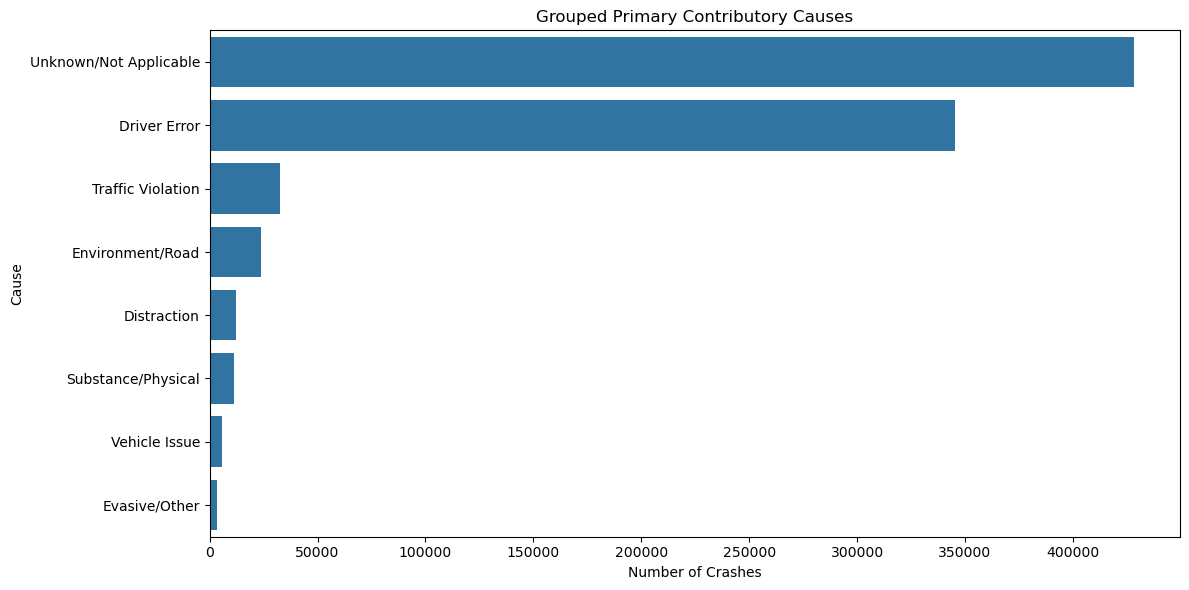

In [15]:
 #Top Primary Contributory Causes (Target)
plt.figure(figsize=(12, 6))
sns.countplot(y=y_grouped, order=y_grouped.value_counts().index)
plt.title('Grouped Primary Contributory Causes')
plt.xlabel('Number of Crashes')
plt.ylabel('Cause')
plt.tight_layout()
plt.show()


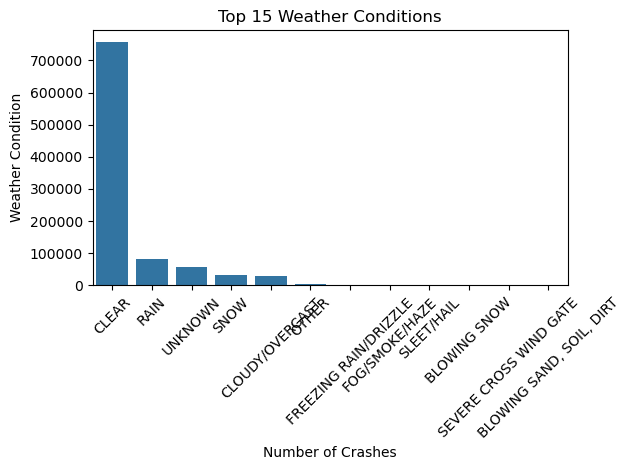

In [16]:
 #Crashes by Weather Condition
plt.Figure(figsize=(12,6))
sns.countplot(x='WEATHER_CONDITION', data=data, order=data['WEATHER_CONDITION'].value_counts().head(15).index)
plt.title('Top 15 Weather Conditions')
plt.xlabel('Number of Crashes')
plt.ylabel('Weather Condition')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
#confirming length of X and y_grouped
print(len(X), len(y_grouped))


962822 962822


In [18]:
#clean y_grouped
mask = y_grouped.notna()
X_clean = X[mask]
y_clean = y_grouped[mask]



In [19]:
#encode the target variable
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y_clean)


In [20]:
#split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_encoded, test_size=0.2, random_state=42)

In [21]:
# Identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Numeric pipeline
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessors
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])


# Objective 1

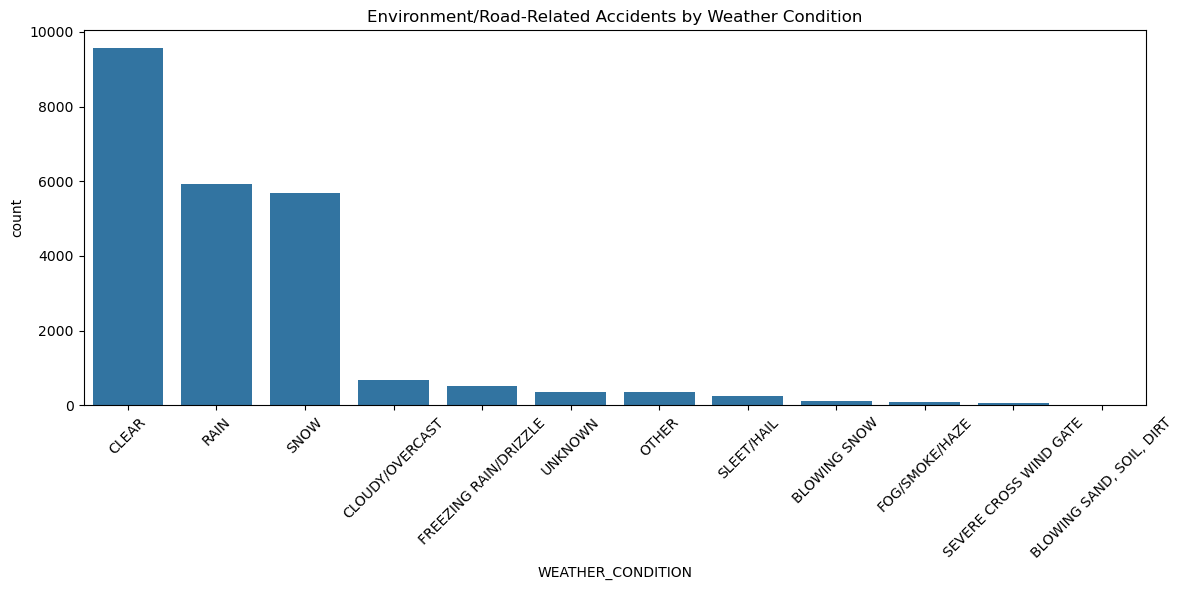

In [29]:
# Bar Plot: Frequency of Environment/Road Causes by WEATHER_CONDITION
env_road_mask = y_clean == 'Environment/Road'
env_road_df = X_clean[env_road_mask]

plt.figure(figsize=(12, 6))
sns.countplot(data=env_road_df, x='WEATHER_CONDITION', order=env_road_df['WEATHER_CONDITION'].value_counts().index)
plt.title('Environment/Road-Related Accidents by Weather Condition')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

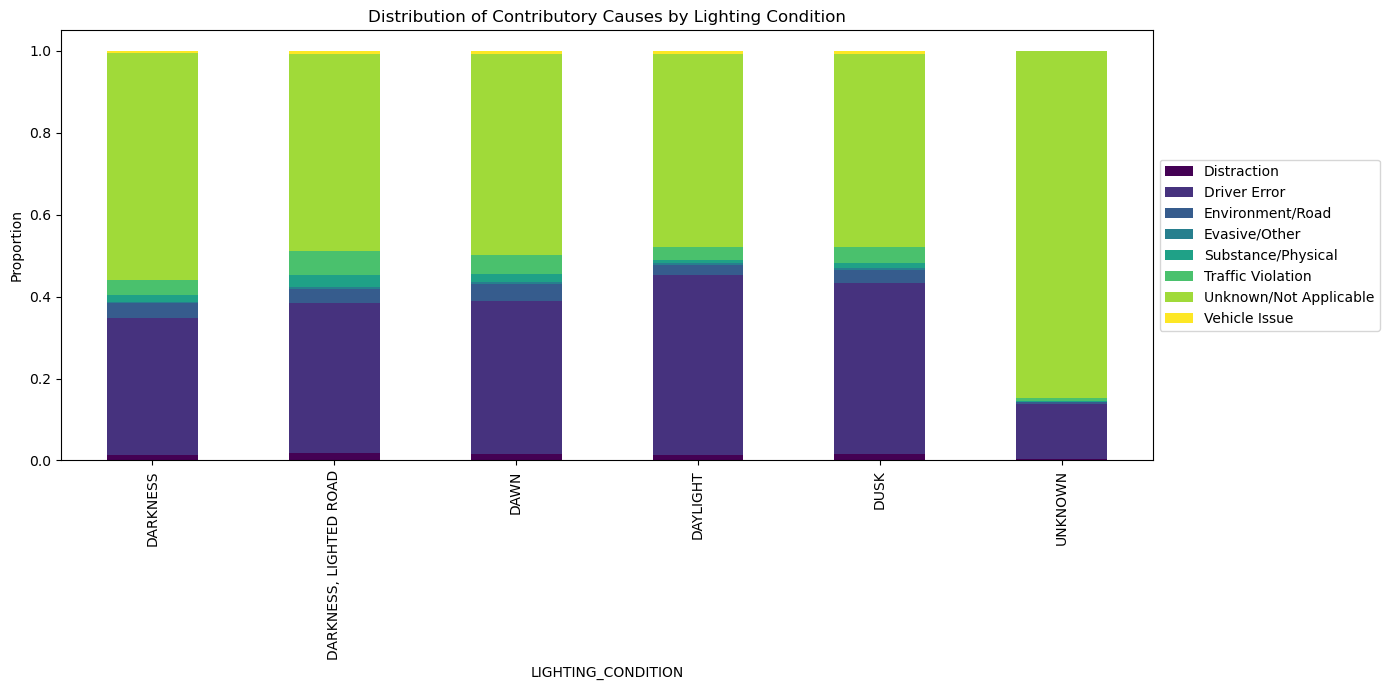

In [31]:
# Stacked Bar: Top Contributing Factors by LIGHTING_CONDITION
# Crosstab
crosstab = pd.crosstab(X_clean['LIGHTING_CONDITION'], y_clean)

# Plot
crosstab_percent = crosstab.div(crosstab.sum(axis=1), axis=0)
crosstab_percent.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='viridis')
plt.title('Distribution of Contributory Causes by Lighting Condition')
plt.ylabel('Proportion')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()


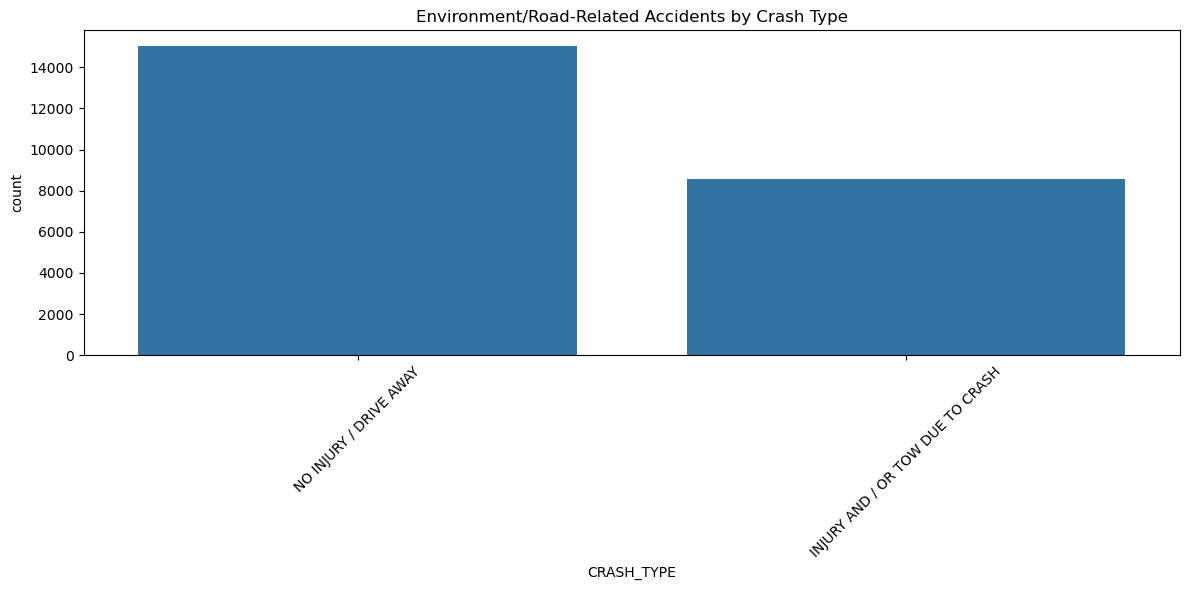

In [33]:

# Bar Plot: Environment/Road Accidents by CRASH_TYPE
# Filter for Environment/Road only
env_road_mask = y_clean == 'Environment/Road'
env_road_df = X_clean[env_road_mask]

# Plot
plt.figure(figsize=(12, 6))
sns.countplot(data=env_road_df, x='CRASH_TYPE', order=env_road_df['CRASH_TYPE'].value_counts().index)
plt.title('Environment/Road-Related Accidents by Crash Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

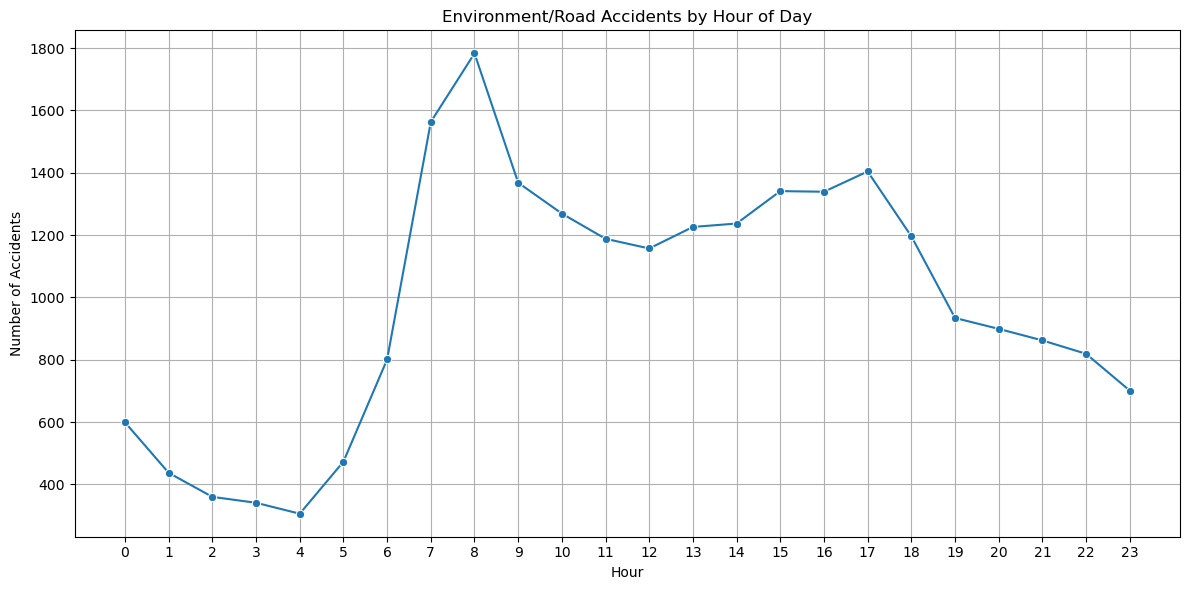

In [34]:
#Time-Based Line Plot: How Environment/Road Accidents Vary by Hour
env_road_by_hour = env_road_df['CRASH_HOUR'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
sns.lineplot(x=env_road_by_hour.index, y=env_road_by_hour.values, marker='o')
plt.title('Environment/Road Accidents by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Accidents')
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()


# Objective 2

### Modelling

### Logistic regression

In [22]:
#build a pipeline for the model
from sklearn.linear_model import LogisticRegression

log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        multi_class='multinomial', 
        solver='lbfgs',
        max_iter=300,
        random_state=42
    ))
])



In [24]:
log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)
print("--- Logistic Regression ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


--- Logistic Regression ---
Accuracy: 0.5898671491281481
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2513
           1       0.54      0.64      0.59     68720
           2       0.45      0.14      0.21      4881
           3       0.66      0.12      0.20       624
           4       0.39      0.01      0.01      2217
           5       0.50      0.32      0.39      6435
           6       0.64      0.64      0.64     85904
           7       0.00      0.00      0.00      1155

    accuracy                           0.59    172449
   macro avg       0.40      0.23      0.25    172449
weighted avg       0.57      0.59      0.57    172449



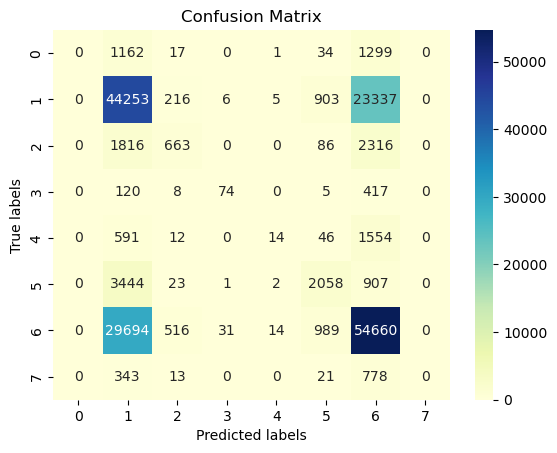

In [25]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix
sns.heatmap(cm, annot=True, cmap="YlGnBu", fmt='g')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

### XGboost

In [24]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=100, 
        max_depth=6, 
        learning_rate=0.1, 
        use_label_encoder=False, 
        eval_metric='mlogloss'
    ))
])


In [28]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("--- XGBoost ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


--- XGBoost ---
Accuracy: 0.5983334203155716
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2513
           1       0.55      0.66      0.60     68720
           2       0.53      0.14      0.22      4881
           3       0.67      0.11      0.19       624
           4       0.50      0.00      0.00      2217
           5       0.52      0.34      0.41      6435
           6       0.65      0.64      0.64     85904
           7       0.00      0.00      0.00      1155

    accuracy                           0.60    172449
   macro avg       0.43      0.24      0.26    172449
weighted avg       0.59      0.60      0.58    172449



In [28]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

model = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(
        use_label_encoder=False, eval_metric='mlogloss'
    ))
])


In [ ]:
#Tuning hyperparameters for XGboost
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [4, 6, 8],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0],
}

search = RandomizedSearchCV(
    model, param_distributions=param_dist,
    n_iter=10, cv=3, scoring='accuracy', verbose=1, n_jobs=-1
)

search.fit(X_train, y_train)
best_model = search.best_estimator_

y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Fitting 3 folds for each of 10 candidates, totalling 30 fits


## Objective 3


### Model interpretability 

   ---------------------------------------- 0.0/545.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/545.1 kB ? eta -:--:--
   ---

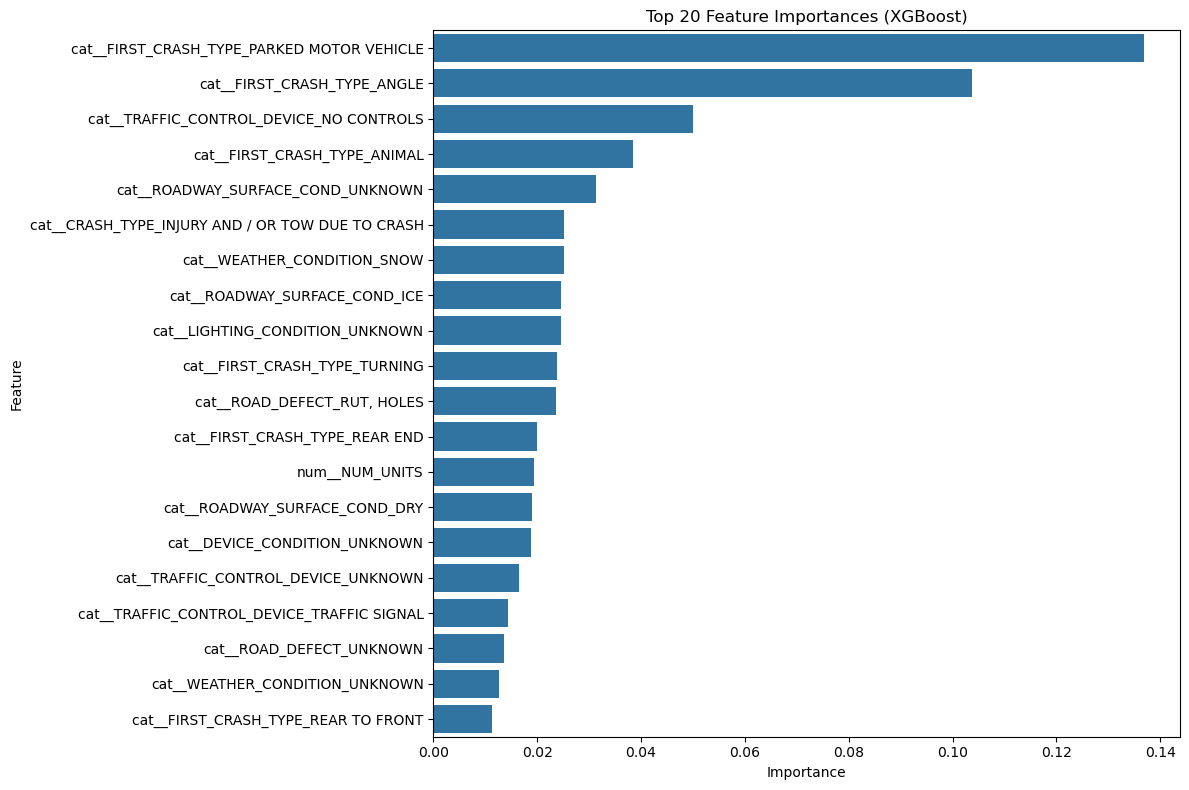

In [26]:

%pip install shap

import shap

# Access model and preprocessor from pipeline
xgb_model = best_model.named_steps['classifier']
preprocessor = best_model.named_steps['preprocessor']

# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

# 1. Feature Importance from XGBoost
importances = xgb_model.feature_importances_
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# Plot top 20 important features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_df.head(20))
plt.title("Top 20 Feature Importances (XGBoost)")
plt.tight_layout()
plt.show()




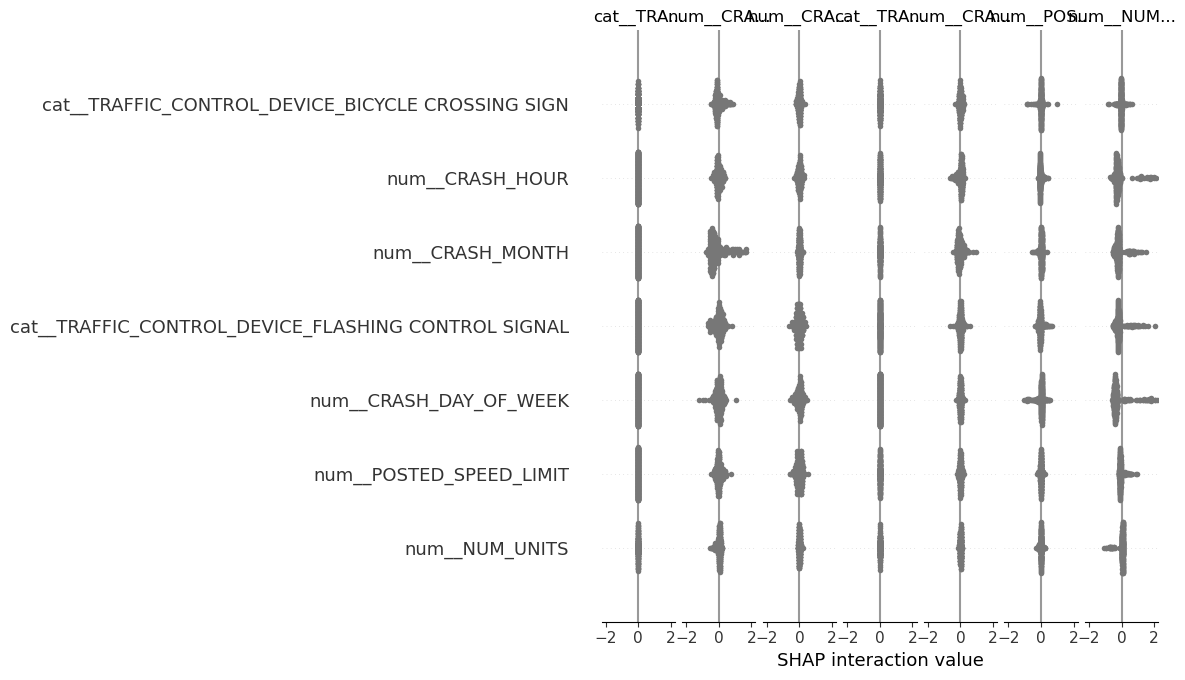

In [27]:
# 2. SHAP Summary Plot (tree explainer)
# Sample the test set to speed things up
X_sample = X_test.sample(300, random_state=42)
X_transformed = preprocessor.transform(X_sample)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_transformed)

# Plot SHAP summary
shap.summary_plot(shap_values, X_transformed, feature_names=feature_names)

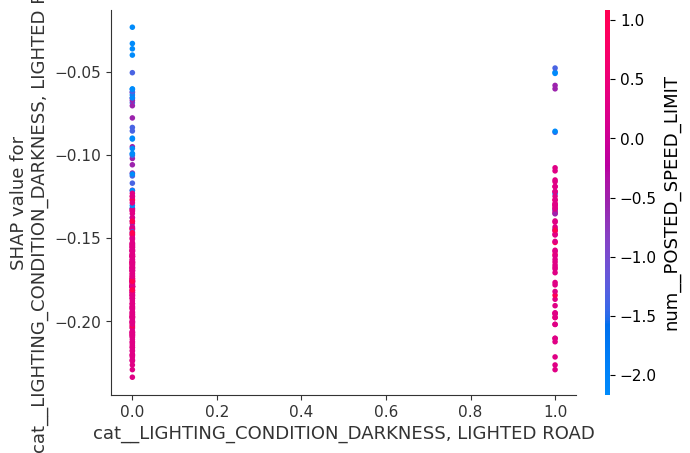

In [43]:
import pandas as pd

# Use the preprocessor to get transformed features
X_sample = X_test.sample(300, random_state=42)
X_transformed = preprocessor.transform(X_sample)

# Turn transformed data into DataFrame with proper feature names
X_transformed_df = pd.DataFrame(X_transformed.toarray(), columns=feature_names)

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_transformed_df)

# For multiclass, select the SHAP values for one class (e.g., class 0)
class_idx = 0  # You can change this to the class index you want to analyze
shap_values_class = shap_values[:, :, class_idx]

# Now plot dependence
shap.dependence_plot(
    'cat__LIGHTING_CONDITION_DARKNESS, LIGHTED ROAD',  
    shap_values_class,
    X_transformed_df,
    feature_names=feature_names
)
